<a href="https://colab.research.google.com/github/raghavkarthikcse2025-coder/daa-lab/blob/main/DAA-OUTPUTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np

# Set a professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

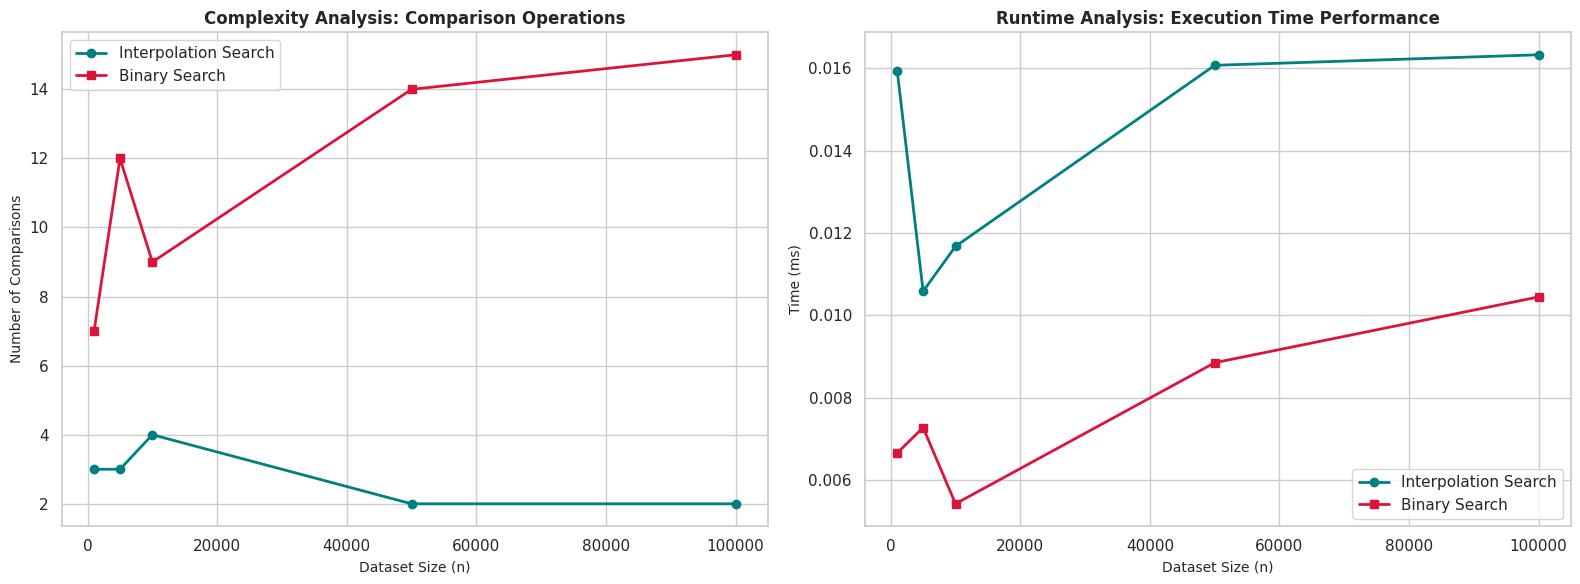

In [2]:
def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            return (low, comparisons) if arr[low] == target else (-1, comparisons)
        pos = low + int(((target - arr[low]) * (high - low)) / (arr[high] - arr[low]))
        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1
    return -1, comparisons

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons

# Performance Benchmarking & Visualization
sizes = [1000, 5000, 10000, 50000, 100000]
is_times, bs_times = [], []
is_comps, bs_comps = [], []

for size in sizes:
    arr = sorted(random.sample(range(size * 10), size))
    target = arr[random.randint(0, size - 1)]

    # Benchmark Interpolation Search
    start = time.perf_counter()
    _, comp_is = interpolation_search(arr, target)
    is_times.append((time.perf_counter() - start) * 1000)
    is_comps.append(comp_is)

    # Benchmark Binary Search
    start = time.perf_counter()
    _, comp_bs = binary_search(arr, target)
    bs_times.append((time.perf_counter() - start) * 1000)
    bs_comps.append(comp_bs)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Comparison Counts
ax1.plot(sizes, is_comps, marker='o', linewidth=2, color='teal', label='Interpolation Search')
ax1.plot(sizes, bs_comps, marker='s', linewidth=2, color='crimson', label='Binary Search')
ax1.set_title('Complexity Analysis: Comparison Operations', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dataset Size (n)', fontsize=10)
ax1.set_ylabel('Number of Comparisons', fontsize=10)
ax1.legend()

# Subplot 2: Execution Time
ax2.plot(sizes, is_times, marker='o', linewidth=2, color='teal', label='Interpolation Search')
ax2.plot(sizes, bs_times, marker='s', linewidth=2, color='crimson', label='Binary Search')
ax2.set_title('Runtime Analysis: Execution Time Performance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dataset Size (n)', fontsize=10)
ax2.set_ylabel('Time (ms)', fontsize=10)
ax2.legend()

plt.tight_layout()
plt.show()

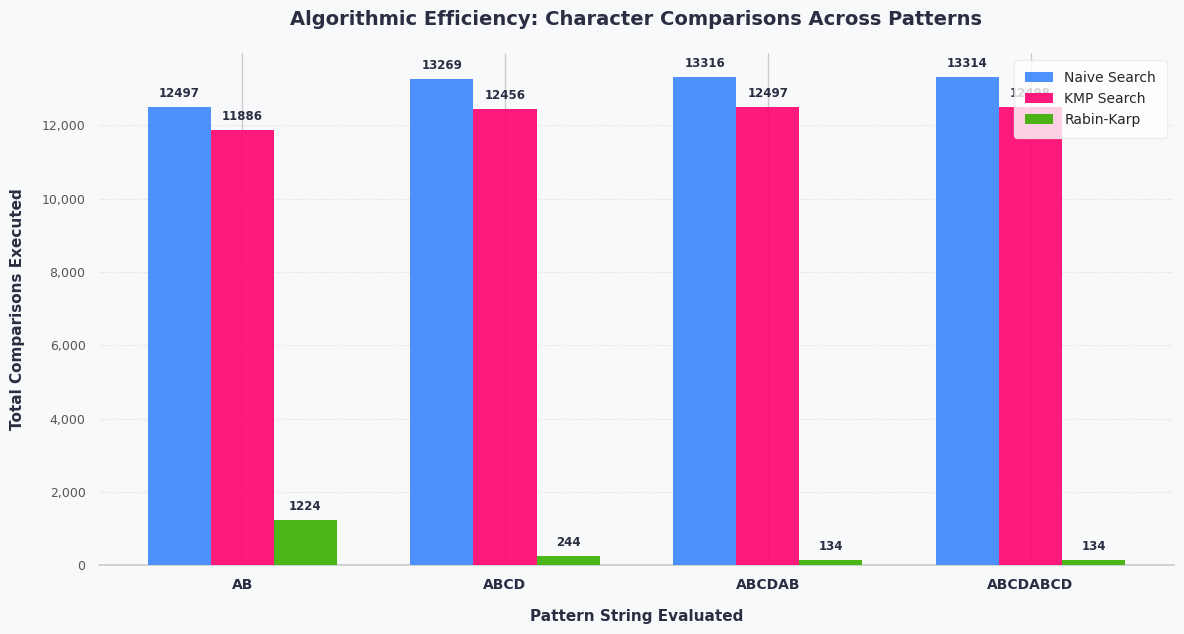

In [9]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Simplified Search Algorithms ---

def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comps = 0
    for i in range(n - m + 1):
        for j in range(m):
            comps += 1
            if text[i + j] != pattern[j]:
                break
    return comps

def compute_lps(pattern):
    lps = [0] * len(pattern)
    length, i = 0, 1
    while i < len(pattern):
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        elif length:
            length = lps[length - 1]
        else:
            i += 1
    return lps

def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)
    comps, i, j = 0, 0, 0

    while i < n:
        comps += 1
        if pattern[j] == text[i]:
            i, j = i + 1, j + 1
            if j == m:
                j = lps[j - 1]
        elif j:
            j = lps[j - 1]
        else:
            i += 1
    return comps

def rabin_karp(text, pattern, q=101):
    n, m = len(text), len(pattern)
    d, h = 256, pow(256, m - 1, q)
    p_hash = t_hash = comps = 0

    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q

    for s in range(n - m + 1):
        if p_hash == t_hash:
            for k in range(m):
                comps += 1
                if text[s + k] != pattern[k]:
                    break
        if s < n - m:
            t_hash = (d * (t_hash - ord(text[s]) * h) + ord(text[s + m])) % q
            if t_hash < 0:
                t_hash += q
    return comps

# --- Benchmarking Setup ---
text_large = ''.join(random.choices('ABCD', k=10000))
patterns = ['AB', 'ABCD', 'ABCDAB', 'ABCDABCD']

algorithms = {
    'Naive Search': naive_search,
    'KMP Search': kmp_search,
    'Rabin-Karp': rabin_karp
}

results = {name: [search_fn(text_large, p) for p in patterns] for name, search_fn in algorithms.items()}

# --- Ultra-Polished Visual Plotting ---
x = np.arange(len(patterns))
width = 0.24  # Reduced slightly to add a clean gap between grouped pattern categories

# Set up a sleek figure style
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=100)
fig.patch.set_facecolor('#F8F9FA')  # Light neutral off-white background
ax.set_facecolor('#F8F9FA')

# Vibrant, modern professional color palette
colors = {
    'Naive Search': '#3A86FF',  # Electric Blue
    'KMP Search': '#FF006E',    # Neon Pink
    'Rabin-Karp': '#38B000'     # Vivid Green
}

# Plot bars and dynamically inject value labels above them
for i, (name, data) in enumerate(results.items()):
    offset = (i - 1) * width
    rects = ax.bar(
        x + offset, data, width,
        label=name, color=colors[name],
        edgecolor='none', alpha=0.9, zorder=3
    )
    # Add exact numeric labels above bars so you don't have to squint at the axis
    ax.bar_label(rects, padding=5, fontsize=8.5, fontweight='bold', color='#2B2D42')

# Styling & Layout Fine-tuning
ax.set_title('Algorithmic Efficiency: Character Comparisons Across Patterns',
             fontsize=14, fontweight='bold', pad=20, color='#2B2D42')
ax.set_xlabel('Pattern String Evaluated', fontsize=11, fontweight='semibold', labelpad=12, color='#2B2D42')
ax.set_ylabel('Total Comparisons Executed', fontsize=11, fontweight='semibold', labelpad=12, color='#2B2D42')

ax.set_xticks(x)
ax.set_xticklabels(patterns, fontsize=10, fontweight='semibold')

# Clean up the chart boundaries (Minimalist theme - remove top, right, and left spines)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.spines['bottom'].set_linewidth(1.2)

# Format y-axis ticks with commas (e.g., 10,000 instead of 10000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{int(val):,}'))
ax.tick_params(axis='y', colors='#555555', labelsize=9)
ax.tick_params(axis='x', colors='#2B2D42')

# Soft horizontal gridlines placed behind the bars
ax.grid(axis='y', linestyle=':', linewidth=0.8, color='#DDDDDD', zorder=0)

# Modern legend placement
ax.legend(
    frameon=True, facecolor='#FFFFFF', edgecolor='#EAEAEA',
    shadow=False, loc='upper right', fontsize=10, borderpad=0.8
)

plt.tight_layout()
plt.show()

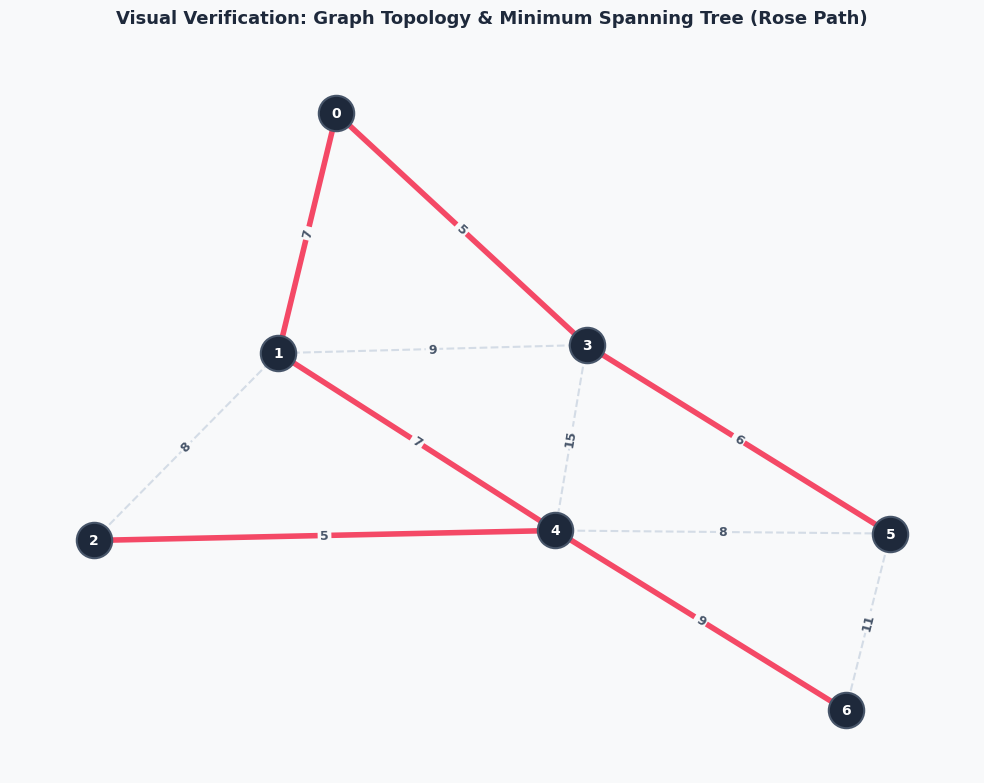

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# --- Simplified Union-Find (Disjoint Set) ---
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # Path compression
        return self.parent[x]

    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        self.parent[ry] = rx
        return True

# --- Kruskal's MST Algorithm ---
def kruskal(n, edges):
    edges.sort()  # Sort by weight automatically (w is the first element)
    uf = UnionFind(n)
    mst = []

    for w, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v))
            if len(mst) == n - 1:
                break
    return mst

# --- Graph Data Configuration ---
n = 7
edges = [
    (7, 0, 1), (5, 0, 3), (8, 1, 2), (9, 1, 3),
    (7, 1, 4), (5, 2, 4), (15, 3, 4), (6, 3, 5),
    (8, 4, 5), (9, 4, 6), (11, 5, 6)
]

# Run layout computation
mst_edges = kruskal(n, edges)

# Build NetworkX Graph
G = nx.Graph()
for w, u, v in edges:
    G.add_edge(u, v, weight=w)

# --- Ultra-Polished Visual Styling ---
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
fig.patch.set_facecolor('#F8F9FA')  # Premium light neutral background
ax.set_facecolor('#F8F9FA')

# Normalize edges to guarantee direction-agnostic matching
mst_set = {tuple(sorted((u, v))) for u, v in mst_edges}
baseline_edges = [(u, v) for u, v in G.edges() if tuple(sorted((u, v))) not in mst_set]
mst_edges_to_draw = [(u, v) for u, v in G.edges() if tuple(sorted((u, v))) in mst_set]

# 1. Draw baseline elements (Non-MST Edges)
nx.draw_networkx_edges(
    G, pos, edgelist=baseline_edges,
    width=1.5, edge_color='#CBD5E1', style='dashed', alpha=0.8
)

# 2. Draw Highlighted MST Path (Vibrant Coral/Rose)
nx.draw_networkx_edges(
    G, pos, edgelist=mst_edges_to_draw,
    width=4.0, edge_color='#F43F5E', alpha=0.95
)

# 3. Draw Nodes (Sleek Slate-Navy)
nx.draw_networkx_nodes(
    G, pos, node_color='#1E293B', node_size=650, edgecolors='#475569', linewidths=1.5
)

# 4. Draw Node Labels (Crisp White Text)
nx.draw_networkx_labels(
    G, pos, font_color='#FFFFFF', font_size=10, font_weight='bold'
)

# 5. Draw Edge Weights (Neat Cutout Labels)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,
    font_color='#475569', font_size=9, font_weight='bold',
    bbox=dict(facecolor='#F8F9FA', edgecolor='none', boxstyle='round,pad=0.2')
)

# Formatting adjustments
plt.title("Visual Verification: Graph Topology & Minimum Spanning Tree (Rose Path)",
          fontsize=13, fontweight='bold', pad=20, color='#1E293B')
plt.axis('off')
plt.tight_layout()
plt.show()

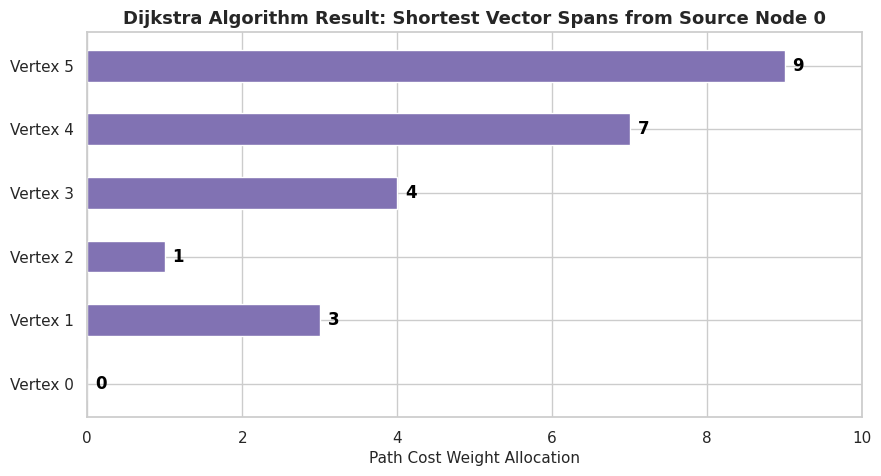

In [5]:
def dijkstra(graph, source):
    n = len(graph)
    dist = [float('inf')] * n
    dist[source] = 0
    pq = [(0, source)]
    visited = set()
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited: continue
        visited.add(u)
        for v, w in graph[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                heapq.heappush(pq, (dist[v], v))
    return dist

# Node Graph Definition
graph = {
    0: [(1, 4), (2, 1)],
    1: [(3, 1)],
    2: [(1, 2), (3, 5)],
    3: [(4, 3)],
    4: [(5, 2)],
    5: []
}

distances = dijkstra(graph, 0)
vertices = [f"Vertex {i}" for i in range(len(graph))]

# Renders relative path distance weights via horizontal chart lines
plt.figure(figsize=(10, 5))
bars = plt.barh(vertices, distances, color='#8172b3', height=0.5)

# Label values onto the paths dynamically
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             va='center', ha='left', fontweight='bold', color='black')

plt.title('Dijkstra Algorithm Result: Shortest Vector Spans from Source Node 0', fontsize=13, fontweight='bold')
plt.xlabel('Path Cost Weight Allocation', fontsize=11)
plt.xlim(0, max(distances) + 1)
plt.show()

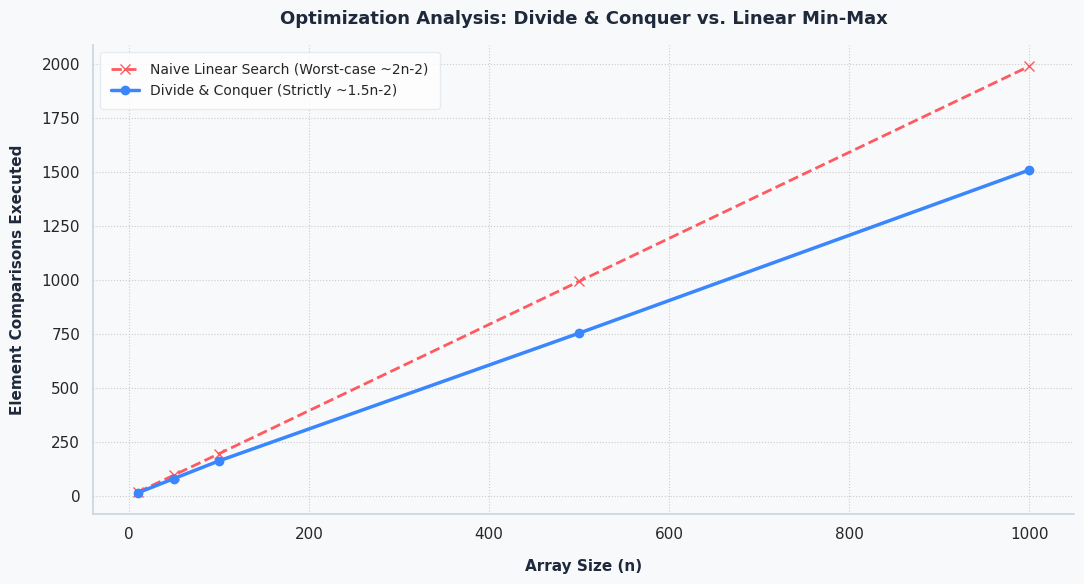

In [11]:
import random
import matplotlib.pyplot as plt

# --- Simplified Search Algorithms (No Global State) ---

def min_max_dc(arr, low, high):
    # Base Case 1: Only one element
    if low == high:
        return arr[low], arr[low], 0

    # Base Case 2: Only two elements
    if high == low + 1:
        if arr[low] < arr[high]:
            return arr[low], arr[high], 1
        return arr[high], arr[low], 1

    # Recursive Case: Divide into halves
    mid = (low + high) // 2
    l_min, l_max, l_comps = min_max_dc(arr, low, mid)
    r_min, r_max, r_comps = min_max_dc(arr, mid + 1, high)

    # 2 additional comparisons to merge the split results
    final_min = l_min if l_min < r_min else r_min
    final_max = l_max if l_max > r_max else r_max

    return final_min, final_max, l_comps + r_comps + 2

def min_max_naive(arr):
    if not arr:
        return None, None, 0

    mn = mx = arr[0]
    comps = 0

    for x in arr[1:]:
        comps += 1
        if x < mn:
            mn = x
        else:
            comps += 1  # Only executed if the first check fails
            if x > mx:
                mx = x

    return mn, mx, comps

# --- Benchmarking Setup ---
sizes = [10, 50, 100, 500, 1000]
results = {"Naive": [], "D&C": []}

for size in sizes:
    test_arr = [random.randint(1, 100000) for _ in range(size)]

    # Run algorithms and capture comparison statistics dynamically
    _, _, dc_comps = min_max_dc(test_arr, 0, len(test_arr) - 1)
    _, _, naive_comps = min_max_naive(test_arr)

    results["D&C"].append(dc_comps)
    results["Naive"].append(naive_comps)

# --- Ultra-Polished Visual Plotting ---
fig, ax = plt.subplots(figsize=(11, 6), dpi=100)
fig.patch.set_facecolor('#F8F9FA')  # Light neutral modern background
ax.set_facecolor('#F8F9FA')

# High-contrast color choices
colors = {
    "Naive": "#FF5A5F",  # Coral Red
    "D&C": "#3A86FF"     # Electric Blue
}

# Plot comparison curves
ax.plot(
    sizes, results["Naive"],
    marker='x', markersize=7, color=colors["Naive"], linestyle='--',
    linewidth=2, label='Naive Linear Search (Worst-case ~2n-2)'
)
ax.plot(
    sizes, results["D&C"],
    marker='o', markersize=6, color=colors["D&C"],
    linewidth=2.5, label='Divide & Conquer (Strictly ~1.5n-2)'
)

# Customizing Typography & Labels
ax.set_title('Optimization Analysis: Divide & Conquer vs. Linear Min-Max',
             fontsize=13, fontweight='bold', pad=15, color='#1E293B')
ax.set_xlabel('Array Size (n)', fontsize=11, fontweight='semibold', labelpad=12, color='#1E293B')
ax.set_ylabel('Element Comparisons Executed', fontsize=11, fontweight='semibold', labelpad=12, color='#1E293B')

# Clean minimalist borders
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CBD5E1')
ax.spines['bottom'].set_linewidth(1.2)

# Soft layout grids
ax.grid(axis='both', linestyle=':', linewidth=0.8, color='#CCCCCC')

# Sophisticated legend positioning
ax.legend(
    frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0',
    loc='upper left', fontsize=10, borderpad=0.8
)

plt.tight_layout()
plt.show()